# Distributed Forecasting — PySpark + Prophet
The canonical pattern for scaling Prophet to thousands of groups.

**Architecture:**
```
Spark DataFrame (all groups)
    ↓  repartition by group key
    ↓  groupby(key).applyInPandas(prophet_udf, schema)
    ↓  one Prophet model trained per partition (parallel workers)
    ↓  results collected into a single Spark DataFrame
```

**Topics:**
1. SparkSession setup with Arrow
2. Synthetic multi-store dataset
3. Single-store sanity check
4. `applyInPandas` UDF — one model per store
5. Forecast analysis in Spark SQL
6. Accuracy KPIs
7. Writing partitioned Parquet output


In [1]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DateType, DoubleType,
)

## 1. SparkSession
Enable Arrow serialisation — this speeds up pandas ↔ Spark data transfer
inside `applyInPandas` by ~10×.

In [2]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("pyspark-prophet-notebook")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "50000")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} ready  |  cores: {spark.sparkContext.defaultParallelism}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/17 08:19:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1 ready  |  cores: 8


## 2. Synthetic Multi-Store Dataset

In [3]:
np.random.seed(42)
STORES = ["store_A", "store_B", "store_C", "store_D"]
START  = date(2021, 1, 1)
DAYS   = 365 * 3

def make_store(store_id, noise_scale=0.1):
    offsets = {"store_A": 0, "store_B": 50, "store_C": -20, "store_D": 80}
    dates = [START + timedelta(days=i) for i in range(DAYS)]
    t     = np.arange(DAYS)
    base  = 300 + offsets[store_id]
    y = (base + 0.05 * t
         + 40 * np.sin(2 * np.pi * t / 365)
         + 20 * np.sin(2 * np.pi * t / 7)
         + np.random.normal(0, noise_scale * base, DAYS))
    return pd.DataFrame({"store": store_id, "ds": dates, "y": y.clip(0)})

history_pd = pd.concat([make_store(s) for s in STORES], ignore_index=True)
print(f"Total rows: {len(history_pd)}")
history_pd.groupby("store")["y"].describe().round(1)

Total rows: 4380


,count,mean,std,min,25%,50%,75%,max
store,,,,,,,,
store_A,1095.0,328.4,43.3,185.4,299.6,328.2,357.7,473.0
store_B,1095.0,378.7,47.0,220.6,346.9,377.5,409.2,549.1
store_C,1095.0,307.5,43.0,185.4,275.7,308.7,337.3,440.2
store_D,1095.0,405.9,49.7,245.7,372.0,407.4,438.5,552.4


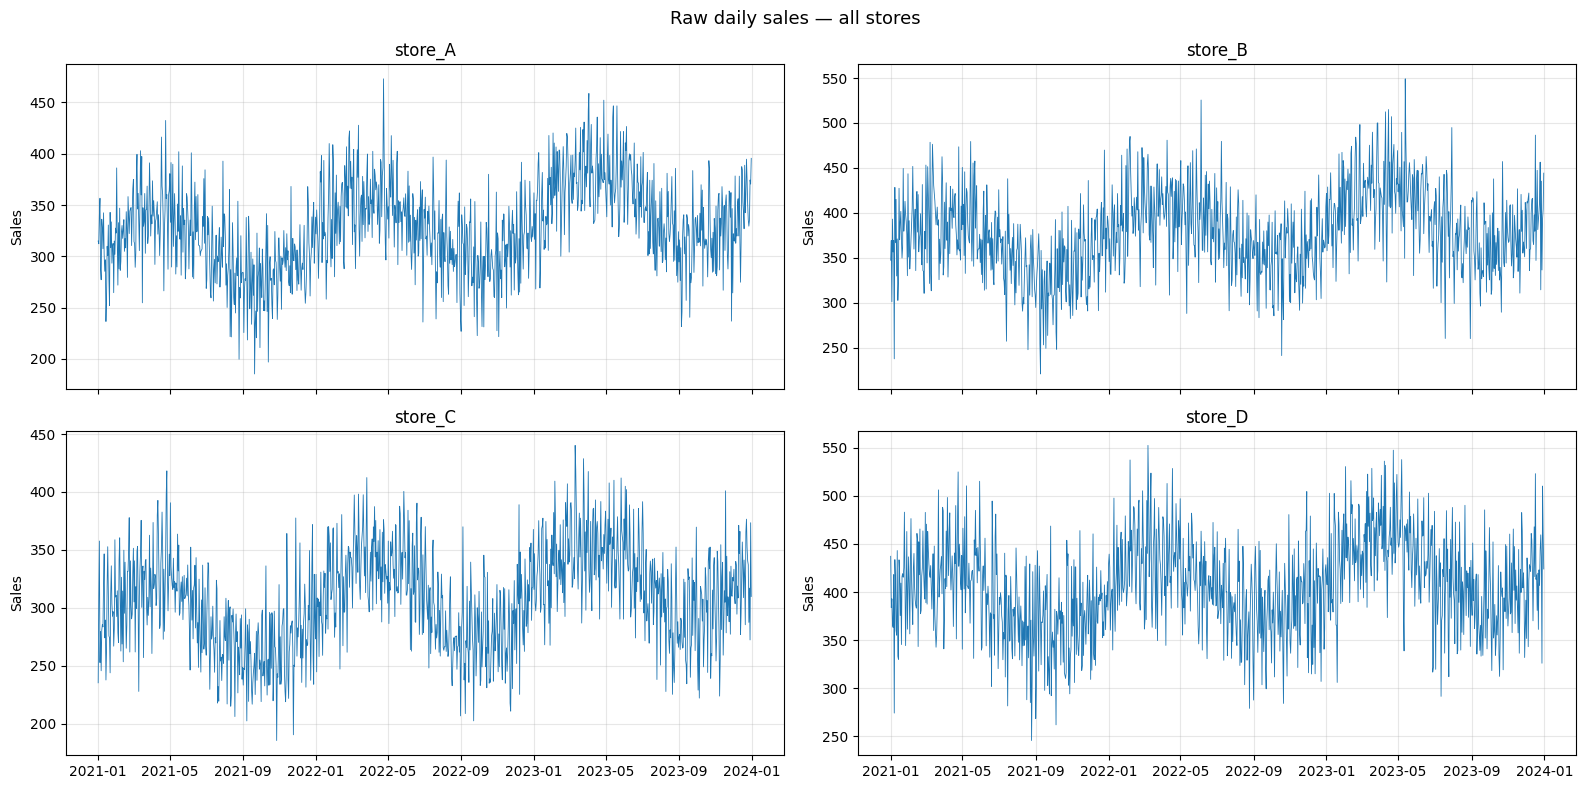

In [4]:
# Plot raw series for all stores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
for ax, store in zip(axes.flat, STORES):
    data = history_pd[history_pd["store"] == store]
    ax.plot(data["ds"], data["y"], linewidth=0.6)
    ax.set_title(store); ax.set_ylabel("Sales"); ax.grid(True, alpha=0.3)
plt.suptitle("Raw daily sales — all stores", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Load into Spark

In [5]:
schema = StructType([
    StructField("store", StringType(), False),
    StructField("ds",    DateType(),   False),
    StructField("y",     DoubleType(), False),
])
sdf = spark.createDataFrame(history_pd, schema=schema)
sdf.printSchema()
sdf.show(5)
print(f"Spark rows: {sdf.count()}")

root
 |-- store: string (nullable = false)
 |-- ds: date (nullable = false)
 |-- y: double (nullable = false)



+-------+----------+------------------+
|  store|        ds|                 y|
+-------+----------+------------------+
|store_A|2021-01-01|  314.901424590337|
|store_A|2021-01-02|312.22723486045845|
|store_A|2021-01-03| 340.4060788515671|
|store_A|2021-01-04|356.58335716352207|
|store_A|2021-01-05|287.24982104804155|
+-------+----------+------------------+
only showing top 5 rows



Spark rows: 4380


## 4. Single-Store Sanity Check
Before distributing, verify Prophet works on one group.

In [6]:
store_a = history_pd[history_pd["store"] == "store_A"][["ds","y"]].copy()
store_a["ds"] = pd.to_datetime(store_a["ds"])

from prophet import Prophet
m_check = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                  seasonality_mode="additive", interval_width=0.90)
m_check.fit(store_a)

fc_check = m_check.predict(m_check.make_future_dataframe(periods=90))
print("Single-store forecast (last 5 rows):")
print(fc_check[["ds","yhat","yhat_lower","yhat_upper"]].tail(5).to_string(index=False))

08:19:28 - cmdstanpy - INFO - Chain [1] start processing


08:19:28 - cmdstanpy - INFO - Chain [1] done processing


Single-store forecast (last 5 rows):
        ds       yhat  yhat_lower  yhat_upper
2024-03-26 388.038617  342.640582  433.061876
2024-03-27 380.765151  331.352556  426.294631
2024-03-28 387.487160  342.857578  435.767072
2024-03-29 402.379980  351.848852  451.051700
2024-03-30 417.007116  367.893652  460.773740


## 5. Distributed Forecast — `applyInPandas`

### How it works
1. `repartition(n_groups, "store")` — one Spark partition per store
2. `groupby("store")` — each worker receives one complete store's DataFrame
3. `applyInPandas(fn, schema)` — Prophet trains & predicts independently per store
4. Results are assembled back into a single Spark DataFrame

### Output schema
Must be declared as a `StructType` before the UDF.


In [7]:
HORIZON = 90

result_schema = StructType([
    StructField("store",       StringType(), False),
    StructField("ds",          DateType(),   False),
    StructField("yhat",        DoubleType(), True),
    StructField("yhat_lower",  DoubleType(), True),
    StructField("yhat_upper",  DoubleType(), True),
    StructField("trend",       DoubleType(), True),
    StructField("is_forecast", StringType(), False),
])

def forecast_store(group_df: pd.DataFrame) -> pd.DataFrame:
    from prophet import Prophet  # import inside UDF — runs on each worker

    store_id = group_df["store"].iloc[0]
    train = group_df[["ds", "y"]].copy()
    train["ds"] = pd.to_datetime(train["ds"])

    if len(train) < 60:  # guard: skip tiny groups
        return pd.DataFrame(columns=[f.name for f in result_schema])

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        seasonality_mode="additive",
        changepoint_prior_scale=0.05,
        interval_width=0.90,
    )
    model.fit(train)

    future   = model.make_future_dataframe(periods=HORIZON, include_history=True)
    forecast = model.predict(future)

    last_date = train["ds"].max()
    forecast["is_forecast"] = forecast["ds"].apply(
        lambda d: "future" if d > last_date else "historical"
    )
    forecast["store"] = store_id

    return (
        forecast[["store","ds","yhat","yhat_lower","yhat_upper","trend","is_forecast"]]
        .assign(ds=lambda df: df["ds"].dt.date)  # DateType, not Timestamp
    )

In [8]:
n_stores = len(STORES)

forecast_sdf = (
    sdf
    .repartition(n_stores, "store")          # one partition per store
    .groupby("store")
    .applyInPandas(forecast_store, schema=result_schema)
    .cache()                                  # materialise once; reuse below
)

print(f"Forecast rows: {forecast_sdf.count()}")
forecast_sdf.show(10)

08:19:35 - cmdstanpy - INFO - Chain [1] start processing
08:19:36 - cmdstanpy - INFO - Chain [1] done processing
08:19:36 - cmdstanpy - INFO - Chain [1] start processing


08:19:36 - cmdstanpy - INFO - Chain [1] start processing


08:19:36 - cmdstanpy - INFO - Chain [1] done processing
08:19:36 - cmdstanpy - INFO - Chain [1] done processing


08:19:37 - cmdstanpy - INFO - Chain [1] start processing


08:19:38 - cmdstanpy - INFO - Chain [1] done processing


Forecast rows: 4740


+-------+----------+------------------+------------------+------------------+------------------+-----------+
|  store|        ds|              yhat|        yhat_lower|        yhat_upper|             trend|is_forecast|
+-------+----------+------------------+------------------+------------------+------------------+-----------+
|store_C|2021-01-01| 277.3881135737471|230.91322703420863|324.86329122066184|281.32131248084505| historical|
|store_C|2021-01-02| 300.5297323848889|255.82263441860192| 346.5857491059764|  281.369116476253| historical|
|store_C|2021-01-03|305.30617258191137| 259.6609088758897| 347.8660440297562|281.41692047166106| historical|
|store_C|2021-01-04| 290.9455886036449| 245.2512470315507| 337.4969407125816|  281.464724467069| historical|
|store_C|2021-01-05| 273.8849356323412|228.75415581351177|321.21916549298766|281.51252846247706| historical|
|store_C|2021-01-06| 267.1989106139674|  221.810431810918| 314.1749389537535|  281.560332457885| historical|
|store_C|2021-01-07

## 6. Spark SQL Analysis

In [9]:
forecast_sdf.createOrReplaceTempView("forecasts")
sdf.createOrReplaceTempView("actuals")

In [10]:
# Accuracy KPIs per store (in-sample / historical rows)
spark.sql("""
    SELECT
        f.store,
        ROUND(SQRT(AVG(POWER(f.yhat - a.y, 2))), 3) AS rmse,
        ROUND(AVG(ABS(f.yhat - a.y)), 3)            AS mae,
        ROUND(AVG(ABS(f.yhat - a.y) / a.y) * 100, 2) AS mape_pct
    FROM forecasts f
    JOIN actuals   a ON f.store = a.store AND f.ds = a.ds
    WHERE f.is_forecast = 'historical'
    GROUP BY f.store
    ORDER BY f.store
""").show()

+-------+------+------+--------+
|  store|  rmse|   mae|mape_pct|
+-------+------+------+--------+
|store_A|28.958|  23.0|    7.19|
|store_B|34.576|27.233|    7.38|
|store_C|27.376|22.005|    7.34|
|store_D|38.299|30.516|    7.72|
+-------+------+------+--------+



In [11]:
# Future 30-day forecast summary
spark.sql("""
    SELECT
        store,
        MIN(ds)             AS forecast_from,
        MAX(ds)             AS forecast_to,
        ROUND(AVG(yhat), 1) AS avg_daily_forecast,
        ROUND(SUM(yhat), 0) AS total_90d_forecast
    FROM forecasts
    WHERE is_forecast = 'future'
    GROUP BY store
    ORDER BY store
""").show()

+-------+-------------+-----------+------------------+------------------+
|  store|forecast_from|forecast_to|avg_daily_forecast|total_90d_forecast|
+-------+-------------+-----------+------------------+------------------+
|store_A|   2024-01-01| 2024-03-30|             386.3|           34768.0|
|store_B|   2024-01-01| 2024-03-30|             430.9|           38781.0|
|store_C|   2024-01-01| 2024-03-30|             360.4|           32437.0|
|store_D|   2024-01-01| 2024-03-30|             458.0|           41223.0|
+-------+-------------+-----------+------------------+------------------+



In [12]:
# Anomaly detection: actual outside 90% prediction interval
spark.sql("""
    SELECT
        f.store, f.ds,
        ROUND(a.y, 2)          AS actual,
        ROUND(f.yhat, 2)       AS forecast,
        ROUND(f.yhat_lower, 2) AS lower_90,
        ROUND(f.yhat_upper, 2) AS upper_90
    FROM forecasts f
    JOIN actuals   a ON f.store = a.store AND f.ds = a.ds
    WHERE f.is_forecast = 'historical'
      AND (a.y < f.yhat_lower OR a.y > f.yhat_upper)
    ORDER BY f.store, f.ds
    LIMIT 20
""").show()

+-------+----------+------+--------+--------+--------+
|  store|        ds|actual|forecast|lower_90|upper_90|
+-------+----------+------+--------+--------+--------+
|store_A|2021-01-07|336.16|  292.76|  242.16|  335.51|
|store_A|2021-01-14|236.49|  291.96|  246.86|  339.08|
|store_A|2021-01-15| 258.5|   306.9|  261.32|  356.61|
|store_A|2021-01-21|342.83|  294.41|  249.99|  341.38|
|store_A|2021-02-01|386.14|  329.59|  281.55|  374.25|
|store_A|2021-02-07|286.35|  341.45|  294.63|  387.83|
|store_A|2021-02-19|279.44|  336.41|  289.82|  380.82|
|store_A|2021-03-16|254.68|  328.63|  279.28|  376.34|
|store_A|2021-03-21|302.94|  355.38|   306.1|  403.05|
|store_A|2021-03-24|368.43|  320.15|  273.67|   367.0|
|store_A|2021-04-17|416.24|  361.44|  314.17|  407.16|
|store_A|2021-04-21|266.37|  325.58|  277.12|  373.45|
|store_A|2021-04-24|432.41|  361.42|  312.93|  408.87|
|store_A|2021-05-06|389.76|  326.66|  280.82|  378.58|
|store_A|2021-05-16|401.93|  349.57|  299.09|  399.36|
|store_A|2

## 7. Visualise Distributed Forecasts in Pandas

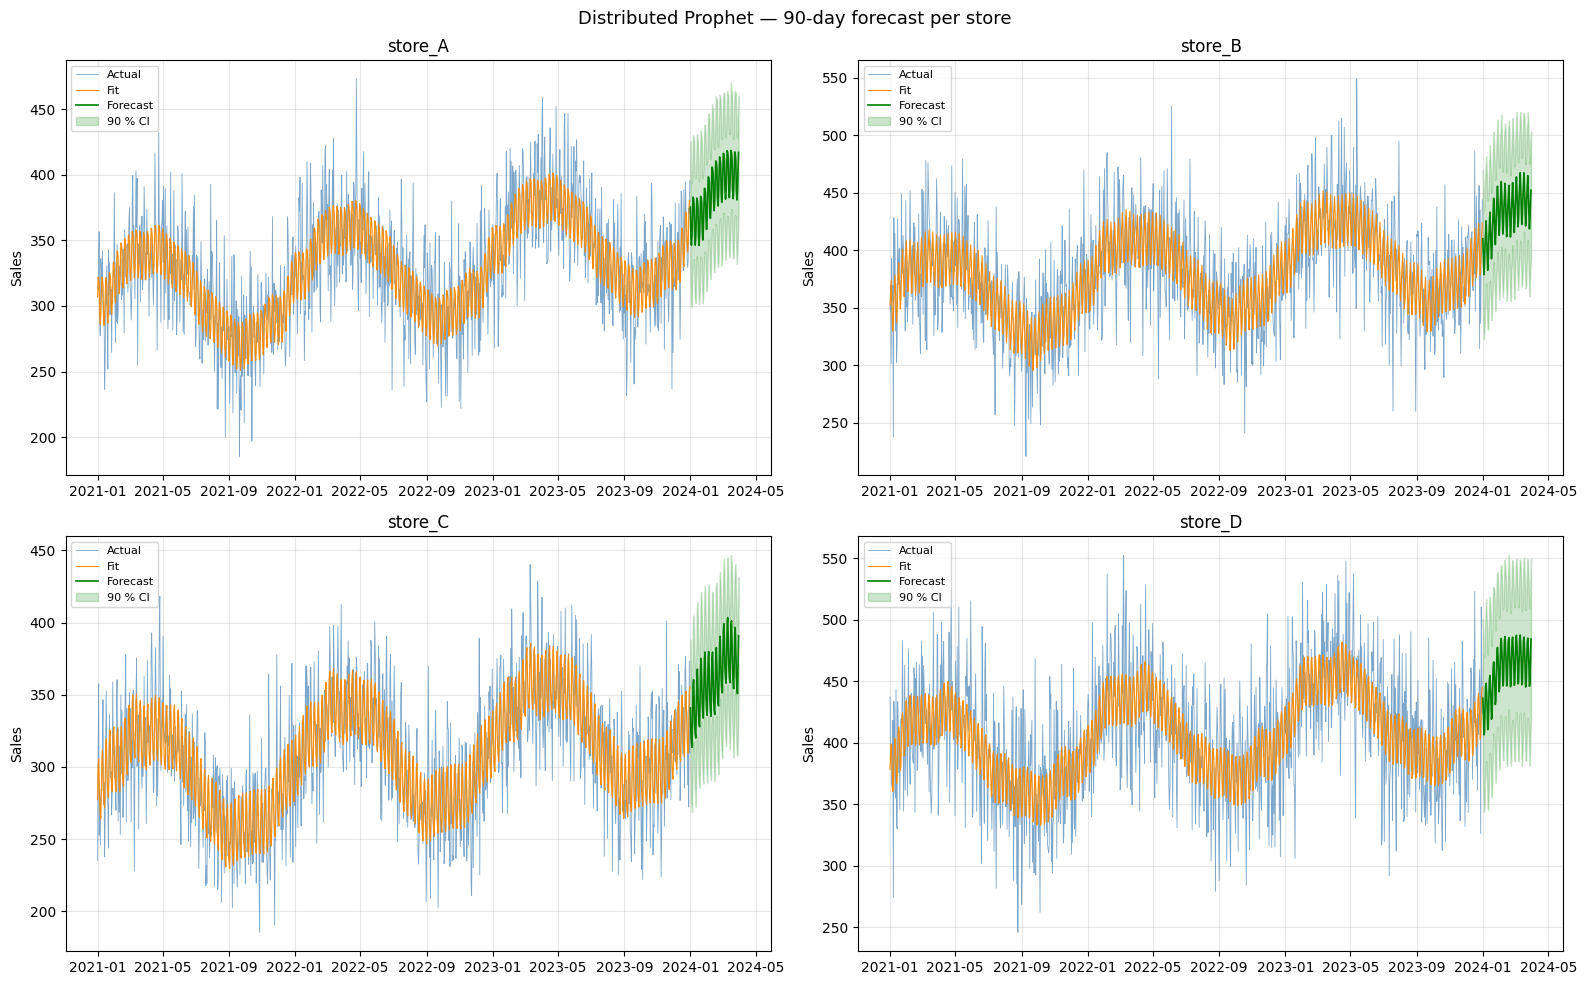

In [13]:
forecast_pd = forecast_sdf.toPandas()
forecast_pd["ds"] = pd.to_datetime(forecast_pd["ds"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, store in zip(axes.flat, STORES):
    fc   = forecast_pd[forecast_pd["store"] == store]
    hist = fc[fc["is_forecast"] == "historical"]
    fut  = fc[fc["is_forecast"] == "future"]
    act  = history_pd[history_pd["store"] == store]

    ax.plot(act["ds"],  act["y"],       color="steelblue", linewidth=0.6, label="Actual", alpha=0.7)
    ax.plot(hist["ds"], hist["yhat"],   color="darkorange",linewidth=0.8, label="Fit")
    ax.plot(fut["ds"],  fut["yhat"],    color="green",     linewidth=1.2, label="Forecast")
    ax.fill_between(fut["ds"], fut["yhat_lower"], fut["yhat_upper"],
                    color="green", alpha=0.2, label="90 % CI")
    ax.set_title(store); ax.set_ylabel("Sales"); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Distributed Prophet — {HORIZON}-day forecast per store", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Write Results to Parquet

In [14]:
OUTPUT_PATH = "/tmp/store_forecasts_parquet"

forecast_sdf.write.mode("overwrite").partitionBy("store").parquet(OUTPUT_PATH)
print(f"Written to {OUTPUT_PATH}")

# Read back and verify
spark.read.parquet(OUTPUT_PATH)     .filter(F.col("is_forecast") == "future")     .orderBy("store", "ds")     .show(10)

Written to /tmp/store_forecasts_parquet


+----------+------------------+------------------+------------------+------------------+-----------+-------+
|        ds|              yhat|        yhat_lower|        yhat_upper|             trend|is_forecast|  store|
+----------+------------------+------------------+------------------+------------------+-----------+-------+
|2024-01-01| 375.3177079569675| 328.7978135661868| 425.5491401451407| 359.4919593835992|     future|store_A|
|2024-01-02| 353.2152984050015| 302.7691125666006|  403.592444165744| 359.5508971158226|     future|store_A|
|2024-01-03| 346.3631244653196| 299.3674371705523|393.75928536023304|  359.609834848046|     future|store_A|
|2024-01-04|353.34948586507505|  306.044848965884| 396.5777534429592|359.66877258026943|     future|store_A|
|2024-01-05| 368.3583438495728|322.47937423664405| 414.3064420130654|359.72771031249283|     future|store_A|
|2024-01-06|382.96493943281433|334.92613335056967|430.19125796115895| 359.7866480447163|     future|store_A|
|2024-01-07| 381.44

In [15]:
spark.stop()